In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jrand

from gvabm.abm_event import sample_event, conditional_sample, build_conditional_sampler
from gvabm.abm_ll import city_ll, eval_ds, eval_ds_hybrid
from gvabm.stat_utils import logrange
from gvabm.param_distr import ParamDistr, param_config, CityParams, EventOutcome, GeneralParams
from gvabm.city_data import subsampled_city_data, subsample_weights
from gvabm.stat_utils import grenander_pdf, hybrid_pdf
param_distr = ParamDistr(param_config)
general_params = param_distr.transform_sample(jnp.array([-7.3749175,  88.287926 ,   0.80230516 , 1.2718915 , -3.294631 ]))

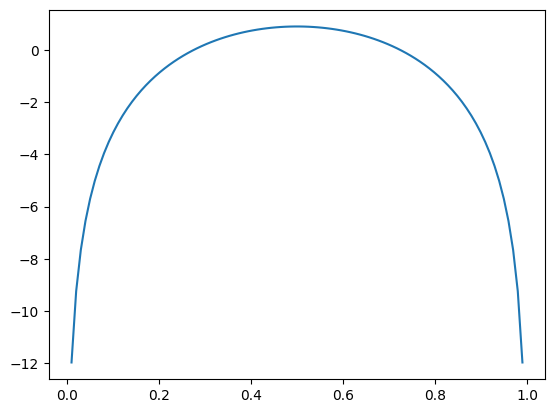

In [4]:
import jax.scipy as jsp
import jax.numpy as jnp
import matplotlib.pyplot as plt

x = jnp.linspace(0, 1, 100)
alpha = 5.0
beta = 5.0
logpdf = jsp.stats.beta.logpdf(x, a=alpha, b=beta)
plt.plot(x, logpdf)
plt.show()

In [ ]:
# from gvabm.abm_event import conditional_sample_batch
num_sample_l = [500 + 99500*(len(c['events']) > 0) for c in subsampled_city_data]
city_param_l = [c['params'] for c in subsampled_city_data]
import time
rng_key = jrand.PRNGKey(0)
sample_iter = conditional_sample_batch(city_param_l, general_params, rng_key, num_sample_l, batch_size=int(1e6))
for i, (n, event_samples) in enumerate(zip(num_sample_l, sample_iter)):
    assert n == len(event_samples)
    # assert all(i == event_samples)
    # print(np.sum(np.abs(event_samples - i)))

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [ ]:
import numpy as np
from gvabm.abm_event import batch_sample

def simple_sample(*args):
    return args[0]

def conditional_sample_batch(city_param_l, general_params, rng_key, num_sample_l, batch_size=int(1e6)):
    batch_param_mat = np.zeros((3*(batch_size // 2), 4)) #hack to deal with overflows
    batch_param_mat_size = 0
    batch_num_samples = []

    prior_batch_sample = None
    
    city_ind = 0
    while city_ind < len(city_param_l):
        while batch_param_mat_size < batch_size:
            num_samples = num_sample_l[city_ind]
            population, population_density, arm_count, arm_density = city_param_l[city_ind]
            propensity, walk_radius, arm_bias, arm_weight, atrisk_gathering_rate = general_params
            param_mat = np.tile(np.array([walk_radius, population_density, 
                                        arm_density*arm_weight+arm_bias, 
                                        atrisk_gathering_rate]).reshape((1, -1)), 
                                        (num_samples, 1))
            batch_param_mat[batch_param_mat_size:batch_param_mat_size+num_samples, :] = param_mat
            batch_param_mat_size += num_samples
            batch_num_samples.append(num_samples)
            city_ind += 1
            if city_ind >= len(city_param_l):
                break

        #run batch
        rng_key, subkey = jrand.split(rng_key, 2)
        rng_batch = jrand.split(rng_key, batch_size)
        batch_event_samples = simple_sample(*[jnp.array(batch_param_mat[:batch_size, i]) for i in range(4)], rng_batch)

        #output batch
        chunked_event_samples = []
        next_prior_batch_sample = None
        si = 0
        for ns in batch_num_samples:
            if si + ns > batch_size:
                next_prior_batch_sample = batch_event_samples[si:]
                batch_num_samples = [(si + ns - batch_size)]
                break
            chunked_event_samples.append(batch_event_samples[si:si+ns])
            si += ns

        if not prior_batch_sample is None:
            chunked_event_samples[0] = jnp.concat([prior_batch_sample, chunked_event_samples[0]])
        prior_batch_sample = next_prior_batch_sample

        for chunk in chunked_event_samples:
            yield chunk
        
        batch_param_mat[:(batch_param_mat_size - batch_size), :] = batch_param_mat[batch_size:batch_param_mat_size, :]
        batch_param_mat_size = (batch_param_mat_size - batch_size)
        # print(f'Batch size: {batch_size}, batch_param_mat_size: {batch_param_mat_size}')
        if not prior_batch_sample is None:
            assert batch_num_samples[0] == batch_param_mat_size
            assert ns == (batch_num_samples[0] + prior_batch_sample.shape[0])